## Loading and Preparing the CHIME data: FRB20190124F

Let's try it! 

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

from scipy.fft import fft, fftfreq, ifft


In [2]:
datadir = "/Users/danielahuppenkothen/work/data/frbs/"
fname = "FRB20190124F_28129879_beamformed.h5"

f = h5py.File(datadir + fname)

In [3]:
print("Using baseband data")

DM = f['tiedbeam_power'].attrs['DM_coherent']  # Same DM used in the paper
baseband = f['tiedbeam_baseband'][:]  # Load baseband data

# Apply coherent dedispersion
print("  Running coherent dedispersion")
freq_fft = fftfreq(
    baseband.shape[-1],
    d=f.attrs["delta_time"] * 1e6,
)
f0 = f['index_map']["freq"]["centre"][:, np.newaxis]
K_DM = 1 / 0.241e-3
H = np.exp(2j * np.pi * 1e6 * K_DM * DM * freq_fft**2 / (freq_fft + f0) / f0 ** 2)  # Intrachannel dispersion transfer function
dedispersed_array = ifft(
    fft(
        np.nan_to_num(
            baseband
        )
    )
    * H[:, np.newaxis]
)  # Dedispersion
dedispersed_array[np.isnan(baseband)]= np.nan  # Mask NaN values in original data
power = np.abs(dedispersed_array) ** 2



Using baseband data
  Running coherent dedispersion


Total intensity
  It has shape (889, 2, 112764) - (frequency channels, linear polarizations, time bins).


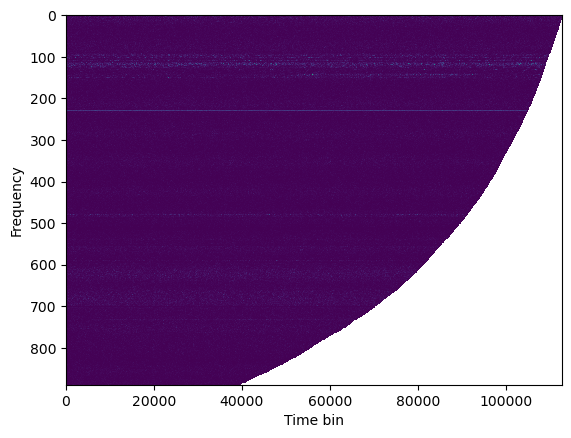

In [4]:
print("Total intensity")
print(f"  It has shape {power.shape} - (frequency channels, linear polarizations, time bins).")
total_intensity = np.mean(power, axis=1)

# Plot the data for visualization
plt.imshow(
    total_intensity,
    interpolation='none',
    aspect='auto'
)
plt.xlabel('Time bin')
plt.ylabel('Frequency')
plt.show()



Fill missing channels


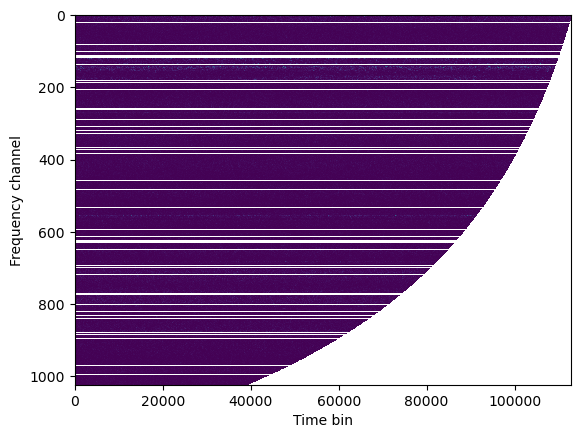

In [5]:
##### Fill missing channels with NaN
print("Fill missing channels")
# Frequency ID of existing channels
freq_id = f['index_map']['freq']['id']
# Waterfall plot containing all channels
waterfall = np.zeros([1024, total_intensity.shape[1]]) + np.nan
# Fill existing channels with values, the rest will be masked with NaNs
waterfall[freq_id] = total_intensity
# Plot the total intensity; all channels are starting at different times 
plt.imshow(
    waterfall,
    interpolation='none',
    aspect='auto'
)
plt.xlabel('Time bin')
plt.ylabel('Frequency channel')
plt.show()


S/N


/var/folders/8b/pp4535m97gs_czr061z789dh0000gn/T/ipykernel_91122/555969589.py:3: RuntimeWarning: Mean of empty slice
  sn = waterfall - np.nanmean(waterfall, axis=1)[:, np.newaxis]
/Users/danielahuppenkothen/work/sw/w/miniforge3/envs/ml/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


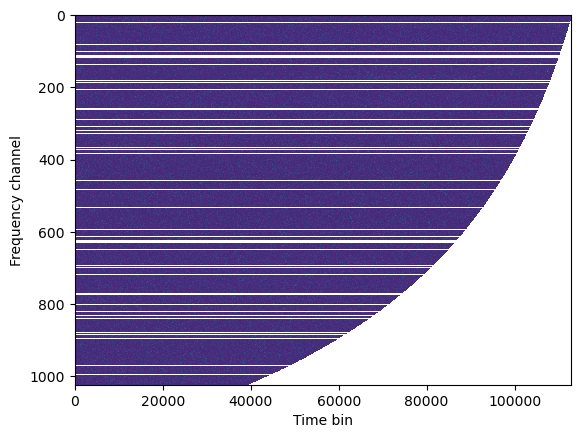

In [6]:
##### Convert to S/N (rough conversion without removing the signal)
print("S/N")
sn = waterfall - np.nanmean(waterfall, axis=1)[:, np.newaxis]
sn /= np.nanstd(sn, axis=1)[:, np.newaxis]
# Plot the total intensity with all channels starting at different times 
plt.imshow(
    sn,
    interpolation='none',
    aspect='auto'
)
plt.xlabel('Time bin')
plt.ylabel('Frequency channel')
plt.show()


Downsampled


/var/folders/8b/pp4535m97gs_czr061z789dh0000gn/T/ipykernel_91122/2745500395.py:8: RuntimeWarning: Mean of empty slice
  np.nanmean(


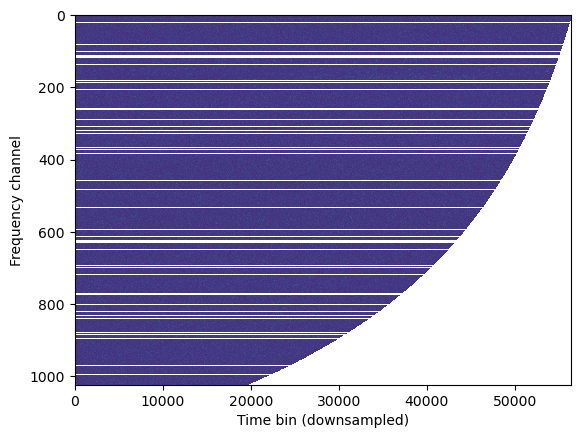

In [7]:
print("Downsampled")
down_factor = 2
sn = sn[..., :sn.shape[-1]//down_factor*down_factor]
# We downsample by summing time bins that are not NaN in each channel
# dividing by the square root of the number of bins summed.
# We use nanmean to keep NaN values since nansum does not
sn_down = (
    np.nanmean(
        sn.reshape(sn.shape[0], sn.shape[1] // down_factor, down_factor),
        axis=-1
    ) * np.sqrt(down_factor)
)
plt.imshow(
    sn_down,
    interpolation='none',
    aspect='auto'
)
plt.xlabel('Time bin (downsampled)')
plt.ylabel('Frequency channel')
plt.show()


RFI excision


/var/folders/8b/pp4535m97gs_czr061z789dh0000gn/T/ipykernel_91122/2691078654.py:14: RuntimeWarning: Mean of empty slice
  spect = np.nanmean(sn_down, axis=1)


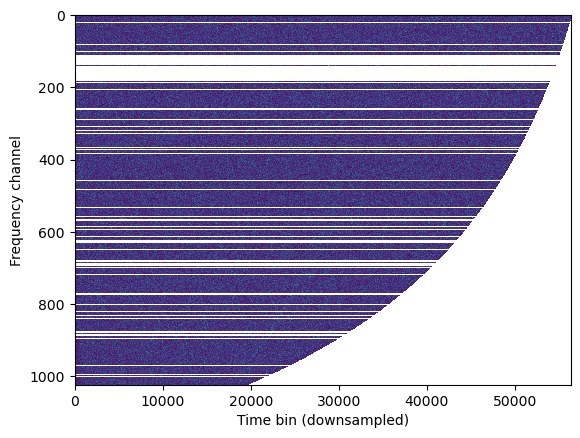

In [8]:
print("RFI excision")
# We do this iteratively three times
sn_threshold = 5
idx_rfi_out = np.zeros(sn_down.shape[0], dtype=bool)
for jj in range(10):
    # Remove channels with standard deviations over 5 times larger than the average
    spect = np.nanstd(sn_down, axis=1)
    spect -= np.nanmedian(spect)
    spect /= np.nanstd(spect)
    idx_rfi = spect > sn_threshold
    sn_down[idx_rfi] = np.nan
    idx_rfi_out = idx_rfi_out | idx_rfi
    # Remove channels with values over 5 times larger than the average
    spect = np.nanmean(sn_down, axis=1)
    spect -= np.nanmedian(spect)
    spect /= np.nanstd(spect)
    idx_rfi = spect > sn_threshold
    sn_down[idx_rfi] = np.nan
    idx_rfi_out = idx_rfi_out | idx_rfi
plt.imshow(
    sn_down,
    interpolation='none',
    aspect='auto'
)
plt.xlabel('Time bin (downsampled)')
plt.ylabel('Frequency channel')
plt.show()


De-dispersed


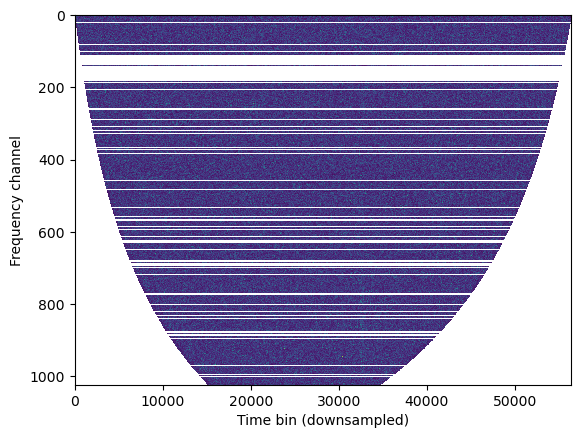

In [9]:
print("De-dispersed")
# Time of beginning of each channel with respect to the earliest one
t0 = f['time0']['ctime'] - f['time0']['ctime'].min()  # seconds
# Frequency value for each channel
freq = f['index_map']['freq']['centre']
# Dedisperse with respect to the top channel
freq_ref = freq.max()
# Use the DM from the realtime pipeline used for coherent dedispersion
dm = f['tiedbeam_power'].attrs['DM_coherent']
# Time resolution
dt = f.attrs['delta_time'] * down_factor  # seconds

# Dedisperse
def incoherent_dedisp(array_in, dm, time0, freq, freq_id, dt=2.56e-6, freq_ref=400):
    array_out = np.zeros_like(array_in) + np.nan
    for t, f, f_id in zip(time0, freq, freq_id):
        dm_delay = dm / 2.41e-4 * (f**-2 - freq_ref**-2)
        bins_shift = np.round((t - dm_delay) / dt).astype(int)
        array_out[f_id] = np.roll(array_in[f_id], bins_shift, axis=-1)
    return array_out
sn_dedisp = incoherent_dedisp(sn_down, dm, t0, freq, freq_id, dt=dt, freq_ref=freq_ref)

plt.imshow(
    sn_dedisp,
    interpolation='none',
    aspect='auto'
)
plt.xlabel('Time bin (downsampled)')
plt.ylabel('Frequency channel')
plt.show()


Final cut


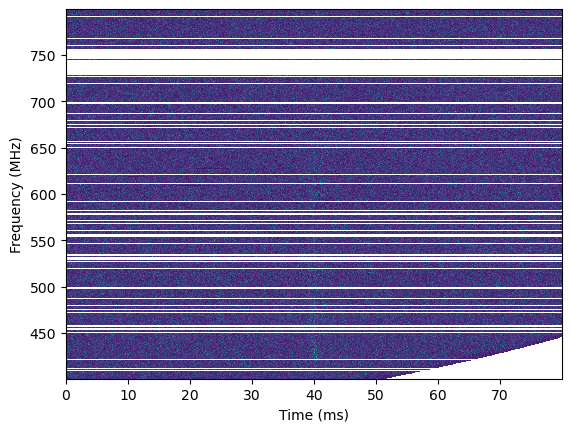

In [10]:
##### Final plot around the burst 
print("Final cut")
# Select a time range
window_ms = 80  # ms
window_bins = int(window_ms / dt / 1000)
profile = np.nansum(sn_dedisp, axis=0) / np.sqrt(np.sum(~np.isnan(np.nansum(sn_dedisp, axis=1))))
bin_start = np.nanargmax(profile) - window_bins // 2
bin_end = np.nanargmax(profile) + window_bins // 2

# Plot the selected interval in physical units
plt.imshow(
    sn_dedisp[:, bin_start:bin_end],
    interpolation='none',
    aspect='auto',
    extent = [
        0,
        (bin_end - bin_start) * dt * 1000,  # ms
        freq.min(),
        freq.max()
    ]
)
plt.xlabel('Time (ms)')
plt.ylabel('Frequency (MHz)')
plt.show()



In [11]:
# Apply previous S/N operations on power
# Fill missing channels with NaN
power_clean = np.zeros([1024, 2, total_intensity.shape[1]]) + np.nan
power_clean[freq_id] = power
# Mask RFI
power_clean[np.isnan(np.nanmean(sn_down, axis=1))] = np.nan
# Dedisperse (incoherently)
power_clean = incoherent_dedisp(power_clean, dm, t0, freq, freq_id, dt=f.attrs['delta_time'], freq_ref=freq_ref)
# Cut around the burst
power_clean = power_clean[..., bin_start*down_factor : bin_end*down_factor]

# Off-pulse region
# Remove any bins in the profile with RMS > 3
off_pulse = profile.copy() - np.nanmedian(profile)
while np.nanmax(np.abs(off_pulse)) > 3:
    off_pulse[np.abs(off_pulse) > 3] = np.nan
    off_pulse -= np.nanmean(off_pulse)
    off_pulse /= np.nanstd(off_pulse)
# Convert to index and increase size to de-downsample
off_pulse = off_pulse[bin_start : bin_end]
idx_off = np.repeat(~ np.isnan(off_pulse), down_factor)
# Create off-pulse power
bg = power_clean[..., idx_off]

# Subtract off-pulse spectrum
spect_off_pulse = np.nanmean(bg, axis=-1)
spectrum = (power_clean - spect_off_pulse[..., np.newaxis])


/var/folders/8b/pp4535m97gs_czr061z789dh0000gn/T/ipykernel_91122/3586204613.py:6: RuntimeWarning: Mean of empty slice
  power_clean[np.isnan(np.nanmean(sn_down, axis=1))] = np.nan
/var/folders/8b/pp4535m97gs_czr061z789dh0000gn/T/ipykernel_91122/3586204613.py:26: RuntimeWarning: Mean of empty slice
  spect_off_pulse = np.nanmean(bg, axis=-1)


In [12]:
# Normalization to transform each channel of the spectrum to Jy
normalization_factor = np.zeros([1024, 2]) + np.nan
normalization_factor[freq_id] = f['index_map']['amplitude_norm']
# Only select cleaned channels without RFI
normalization_factor[np.isnan(np.nanmean(sn_down, axis=1))] = np.nan

# Fluence calculated as the rectangular integral of the normalized profile
fluence = np.nansum(  # Sum the two polarizations
    np.nanmean(spectrum, axis=0) /  # Spectrum mean along frequency (time and pol. preserved)
    np.nanmean(normalization_factor, axis=0)[:, np.newaxis]  # Normalization mean along frequency
) * f.attrs['delta_time'] * 1e3  # Time resolution in ms

print(f"  Fluence = {fluence:.0f} Jy ms")



/var/folders/8b/pp4535m97gs_czr061z789dh0000gn/T/ipykernel_91122/1417589182.py:5: RuntimeWarning: Mean of empty slice
  normalization_factor[np.isnan(np.nanmean(sn_down, axis=1))] = np.nan


  Fluence = 32 Jy ms


In [13]:
flux = np.nansum(sn_dedisp[:, bin_start:bin_end], axis=0)

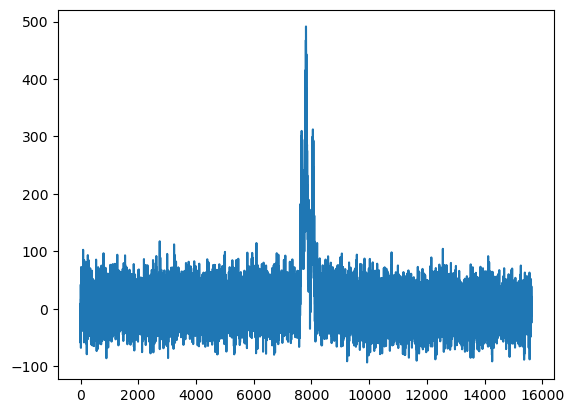

In [19]:
plt.plot(flux)
plt.xlim(7400, 8400)

In [38]:
len(flux)

3906

In [20]:
mean_flux = np.mean(flux[:1000])
var_flux = np.std(flux[:1000])

print(f"mean flux : {mean_flux}")
print(f"var flux: {var_flux}")

mean flux : 8.28411217627691
var flux: 28.086159056068908


In [21]:
snr = (flux - mean_flux) / var_flux

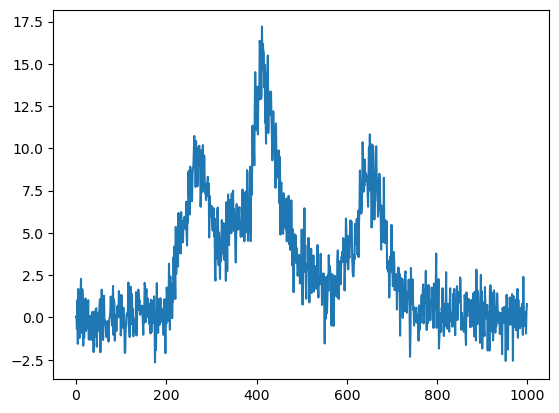

In [22]:
plt.plot(snr[7400:8400])
#plt.xlim(1500, 2500)

In [23]:
print(f"mean snr : {np.mean(snr[:1000])}")
print(f"std snr: {np.std(snr[:1000])}")

mean snr : 9.947598300641403e-17
std snr: 1.0


In [24]:
np.savetxt(f"{datadir}FRB20190124F_lc.dat", snr[7400:8400])